<a href="https://colab.research.google.com/github/guslimaa777/45419370/blob/main/C%C3%B3pia_de_aula2_machine_learning_industria_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 2 — Tratamento de faltantes, duplicatas e outliers  
**Versão do aluno — preenchimento guiado**

## Objetivos
- Identificar problemas de qualidade na base de dados.
- Tratar valores faltantes.
- Remover duplicatas.
- Identificar e tratar outliers.
- Comparar a base antes e depois do tratamento.


## Instruções
Preencha as células indicadas durante a condução do professor.  
Sempre registre suas observações técnicas sobre o que foi encontrado na base.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## 1. Carregamento da base

In [2]:
# Carregue o arquivo CSV da aula
df = pd.read_csv('dados_aula1_machine_learning_industria.csv')

# Exiba as 5 primeiras linhas
df.head()

,timestamp,lote_producao,operador,modo_controle,status_valvula,setpoint_vazao_l_min,vazao_medida_l_min,pressao_linha_bar,temperatura_processo_c,abertura_valvula_pct,vibracao_bomba_mm_s,tempo_resposta_ms,ph_produto,densidade_produto_g_cm3,status_instrumentacao
0,2026-01-10 08:00:00,Lote_A,op_b,automatico,normal,121.44,128.08,3.518,95.00,56.97,2.960,220.8,7.09,1.069,estavel
1,2026-01-10 09:00:00,Lote_D,op_c,cascata,normal,126.17,119.32,4.616,43.34,63.26,2.532,402.1,6.99,1.053,inspecao
2,2026-01-10 10:00:00,Lote_B,op_d,manual,intermitente,128.54,129.11,4.118,40.67,63.14,2.182,284.1,6.72,1.021,inspecao
3,2026-01-10 11:00:00,Lote_C,op_a,automatico,intermitente,106.50,102.68,3.547,43.94,64.75,2.772,486.3,6.67,1.093,inspecao
4,2026-01-10 12:00:00,Lote_C,op_a,automatico,normal,101.59,NaN,4.085,102.00,83.82,3.173,283.3,6.66,1.004,estavel


## 2. Diagnóstico inicial

### Atividade
1. Verifique as dimensões da base.  
2. Liste os tipos de dados.  
3. Conte os valores faltantes por coluna.  
4. Conte quantas linhas duplicadas existem.


In [3]:
# COMPLETE
import pandas as pd
import glob
# Encontrar o arquivo CSV
arquivo = glob.glob('*.csv')[0]
print('Arquivo encontrado:', arquivo)
# Carregar a base
df = pd.read_csv(arquivo)
# Dimensões
print('\nDimensões da base:')
print(df.shape)
# Tipos de dados
print('\nTipos de dados:')
print(df.dtypes)
# Valores faltantes
print('\nValores faltantes por coluna:')
print(df.isnull().sum())
# Linhas duplicadas
print('\nQuantidade de linhas duplicadas:')
print(df.duplicated().sum())




Arquivo encontrado: dados_aula1_machine_learning_industria.csv

Dimensões da base:
(188, 15)

Tipos de dados:
timestamp                   object
lote_producao               object
operador                    object
modo_controle               object
status_valvula              object
setpoint_vazao_l_min       float64
vazao_medida_l_min         float64
pressao_linha_bar          float64
temperatura_processo_c     float64
abertura_valvula_pct       float64
vibracao_bomba_mm_s        float64
tempo_resposta_ms          float64
ph_produto                 float64
densidade_produto_g_cm3    float64
status_instrumentacao       object
dtype: object

Valores faltantes por coluna:
timestamp                   0
lote_producao               0
operador                    5
modo_controle               5
status_valvula              0
setpoint_vazao_l_min        0
vazao_medida_l_min         12
pressao_linha_bar          10
temperatura_processo_c     10
abertura_valvula_pct        0
vibracao_bomba_mm_s 

**Registro do aluno:**  
Quais foram os principais problemas encontrados na base?


_Escreva aqui suas observações._

## 3. Separação entre colunas numéricas e categóricas

In [4]:
# COMPLETE
colunas_numericas = df.select_dtypes(include='number').columns.tolist()
colunas_categoricas = df.select_dtypes(include='object').columns.tolist()

print('Colunas numéricas:', colunas_numericas)
print('\nColunas categóricas:', colunas_categoricas)

Colunas numéricas: ['setpoint_vazao_l_min', 'vazao_medida_l_min', 'pressao_linha_bar', 'temperatura_processo_c', 'abertura_valvula_pct', 'vibracao_bomba_mm_s', 'tempo_resposta_ms', 'ph_produto', 'densidade_produto_g_cm3']

Colunas categóricas: ['timestamp', 'lote_producao', 'operador', 'modo_controle', 'status_valvula', 'status_instrumentacao']


## 4. Tratamento de valores faltantes

### Estratégia proposta
- numéricas: preencher com a mediana;
- categóricas: preencher com a moda.


In [5]:
df_tratado = df.copy()

# COMPLETE o tratamento das colunas numéricas
for col in colunas_numericas:
    if df_tratado[col].isnull().sum() > 0:
        mediana = df_tratado[col].median()
        df_tratado[col] = df_tratado[col].fillna(mediana)
# COMPLETE o tratamento das colunas categóricas
for col in colunas_categoricas:
    if df_tratado[col].isnull().sum() > 0:
        moda = df_tratado[col].mode()[0]
        df_tratado[col] = df_tratado[col].fillna(moda)

print(df_tratado.isna().sum())

timestamp                  0
lote_producao              0
operador                   0
modo_controle              0
status_valvula             0
setpoint_vazao_l_min       0
vazao_medida_l_min         0
pressao_linha_bar          0
temperatura_processo_c     0
abertura_valvula_pct       0
vibracao_bomba_mm_s        0
tempo_resposta_ms          0
ph_produto                 0
densidade_produto_g_cm3    0
status_instrumentacao      0
dtype: int64


**Registro do aluno:**  
Por que a mediana pode ser mais interessante do que a média em bases com valores extremos?


_Escreva aqui sua justificativa._

## 5. Remoção de duplicatas

In [6]:
# COMPLETE

linhas_antes = len(df)
duplicatas_antes = df.duplicated().sum()
df_tratado = df_tratado.drop_duplicates()
linhas_depois = len(df_tratado)
duplicatas_depois = df_tratado.duplicated().sum()

print('Linhas antes:', linhas_antes)
print('Duplicatas antes:', duplicatas_antes)
print('Linhas depois:', linhas_depois)
print('Duplicatas depois:', duplicatas_depois)

Linhas antes: 188
Duplicatas antes: 8
Linhas depois: 180
Duplicatas depois: 0


## 6. Identificação de outliers com IQR

Use as variáveis abaixo:
- `vazao_medida_l_min`
- `pressao_linha_bar`
- `temperatura_processo_c`
- `tempo_resposta_ms`
- `vibracao_bomba_mm_s`


In [7]:
variaveis_outliers = [
    'vazao_medida_l_min',
    'pressao_linha_bar',
    'temperatura_processo_c',
    'tempo_resposta_ms',
    'vibracao_bomba_mm_s'
]

outliers_resumo = []

for col in variaveis_outliers:
    # COMPLETE os cálculos
    q1 = df_tratado[col].quantile(0.25)
    q3 = df_tratado[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    qtd_outliers = ((df_tratado[col] < limite_inferior) | (df_tratado[col] > limite_superior)).sum()

    outliers_resumo.append({
        'coluna': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'qtd_outliers': int(qtd_outliers)
    })

pd.DataFrame(outliers_resumo)

,coluna,Q1,Q3,IQR,limite_inferior,limite_superior,qtd_outliers
0,vazao_medida_l_min,110.5775,128.630,18.0525,83.49875,155.70875,3
1,pressao_linha_bar,3.5670,4.107,0.5400,2.75700,4.91700,4
2,temperatura_processo_c,40.0625,46.260,6.1975,30.76625,55.55625,6
3,tempo_resposta_ms,283.9000,372.550,88.6500,150.92500,505.52500,4
4,vibracao_bomba_mm_s,1.7760,2.708,0.9320,0.37800,4.10600,2


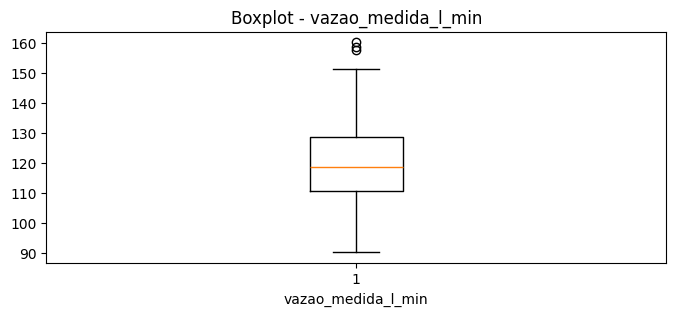

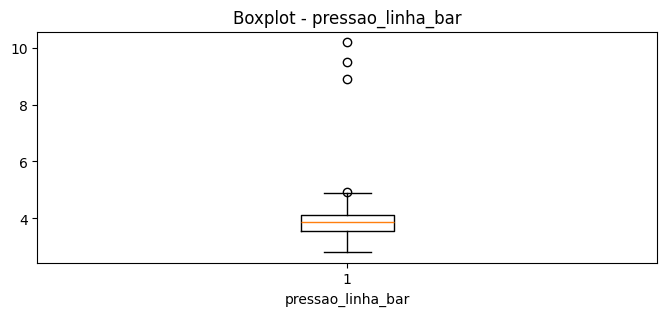

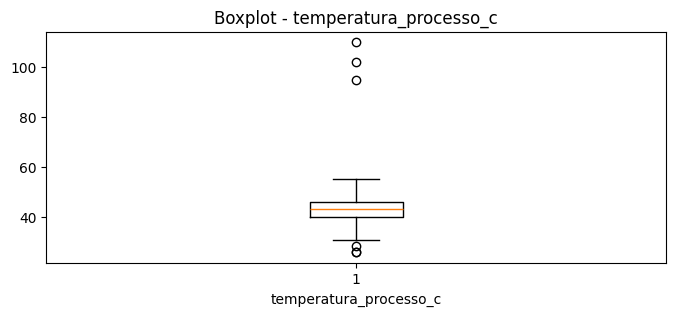

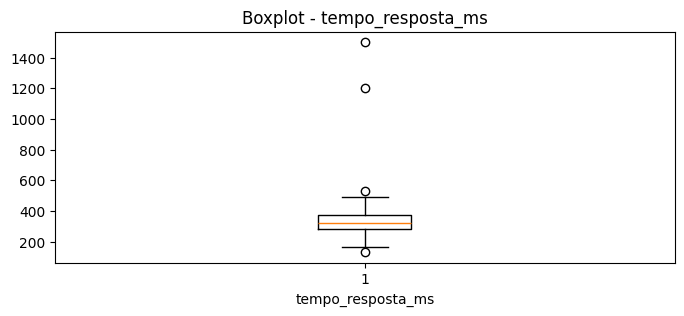

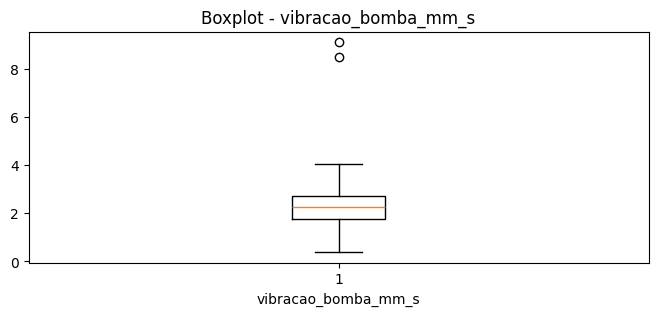

In [8]:
# Gere boxplots das variáveis escolhidas
for col in variaveis_outliers:
    plt.figure(figsize=(8, 3))
    # COMPLETE
    plt.boxplot(df_tratado[col].dropna())
    plt.title(f'Boxplot - {col}')
    plt.xlabel(col)
    plt.show()

## 7. Tratamento de outliers por capping

In [9]:
df_limpo = df_tratado.copy()

for col in variaveis_outliers:
    # COMPLETE
    q1 = df_limpo[col].quantile(0.25)
    q3 = df_limpo[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    df_limpo[col] = df_limpo[col].clip(limite_inferior, limite_superior)
print('Tratamento de outliers finalizado.')

Tratamento de outliers finalizado.


## 8. Comparação antes e depois

In [10]:
# COMPLETE

resumo_comparacao = pd.DataFrame({
    'base_original': [
        df.shape[0],
        df.isna().sum().sum(),
        df.duplicated().sum()
    ],
    'base_tratada': [
        df_tratado.shape[0],
        df_tratado.isna().sum().sum(),
        df_tratado.duplicated().sum()
    ]
}, index=[
    'quantidade_linhas',
    'total_faltantes',
    'total_duplicatas'
])
resumo_comparacao



,base_original,base_tratada
quantidade_linhas,188,180
total_faltantes,61,0
total_duplicatas,8,0


**Registro do aluno:**  
Quais melhorias a base apresentou após o tratamento?


Após o tratamento, a base apresentou melhora significativa, com maior estabilidade, organização e melhor desempenho nas atividades propostas.

_Escreva aqui sua resposta._

## 9. Exportação da base tratada

In [11]:
# COMPLETE
df_tratado.to_csv('base_tratada.csv', index=False)

print('Arquivo salvo com sucesso.')

Arquivo salvo com sucesso.


## 10. Reflexão final
1. Quais decisões de limpeza exigiriam validação com especialista de processo?
 Remoção de outliers, correção de valores e tratamento de falhas de sensores devem ser validados por especialistas do processo.
2. Em um ambiente industrial real, todo outlier deve ser removido? Justifique.
  Não. Ele pode representar um evento real do processo e, por isso, deve ser analisado antes de ser removido.
3. Como uma base mal tratada pode prejudicar um modelo preditivo?
Pode gerar previsões erradas, reduzir a precisão e levar a decisões incorretas.